In [ ]:
from google.colab import files
uploaded = files.upload()

Saving data.csv to data.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
df = pd.read_csv("data.csv")

df.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


In [ ]:
df.shape

(6819, 96)

In [ ]:
df.columns

Index(['Bankrupt?', ' ROA(C) before interest and depreciation before interest',
       ' ROA(A) before interest and % after tax',
       ' ROA(B) before interest and depreciation after tax',
       ' Operating Gross Margin', ' Realized Sales Gross Margin',
       ' Operating Profit Rate', ' Pre-tax net Interest Rate',
       ' After-tax net Interest Rate',
       ' Non-industry income and expenditure/revenue',
       ' Continuous interest rate (after tax)', ' Operating Expense Rate',
       ' Research and development expense rate', ' Cash flow rate',
       ' Interest-bearing debt interest rate', ' Tax rate (A)',
       ' Net Value Per Share (B)', ' Net Value Per Share (A)',
       ' Net Value Per Share (C)', ' Persistent EPS in the Last Four Seasons',
       ' Cash Flow Per Share', ' Revenue Per Share (Yuan ¥)',
       ' Operating Profit Per Share (Yuan ¥)',
       ' Per Share Net profit before tax (Yuan ¥)',
       ' Realized Sales Gross Profit Growth Rate',
       ' Operating Profit

In [ ]:
df.isnull().sum()

,0
Bankrupt?,0
ROA(C) before interest and depreciation before interest,0
ROA(A) before interest and % after tax,0
ROA(B) before interest and depreciation after tax,0
Operating Gross Margin,0
...,...
Liability to Equity,0
Degree of Financial Leverage (DFL),0
Interest Coverage Ratio (Interest expense to EBIT),0
Net Income Flag,0


In [ ]:
df["Risk_Level"] = df["Bankrupt?"]

In [ ]:
df["Risk_Level"] = df["Risk_Level"].replace({
0: "Low",
1: "High"
})

In [ ]:
df[["Bankrupt?", "Risk_Level"]].head()

,Bankrupt?,Risk_Level
0,1,High
1,1,High
2,1,High
3,1,High
4,1,High


In [ ]:
df["Risk_Level"] = df["Risk_Level"].replace({
"Low": 0,
"High": 2
})

/tmp/ipykernel_4238/1141407713.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Risk_Level"] = df["Risk_Level"].replace({


In [ ]:
df["Risk_Level"].value_counts()

,count
Risk_Level,
0,6599
2,220


In [ ]:
X = df.drop(["Bankrupt?", "Risk_Level"], axis=1)
y = df["Risk_Level"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
predictions = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, predictions)

0.9648093841642229

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1313
           2       0.64      0.14      0.23        51

    accuracy                           0.96      1364
   macro avg       0.80      0.57      0.60      1364
weighted avg       0.96      0.96      0.95      1364



In [ ]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, predictions)

array([[1309,    4],
       [  44,    7]])

In [ ]:
import pandas as pd

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance.sort_values(ascending=False).head(10)

,0
Net Income to Stockholder's Equity,0.034639
Working Capital/Equity,0.024682
Borrowing dependency,0.024263
Degree of Financial Leverage (DFL),0.022686
Net Income to Total Assets,0.022634
Persistent EPS in the Last Four Seasons,0.022169
Interest Expense Ratio,0.019848
Non-industry income and expenditure/revenue,0.019513
Net Value Per Share (A),0.019337
Cash/Total Assets,0.019164


In [ ]:
model.predict(X_test[:1])

array([0])

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=200)
}

for name, model in models.items():

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    print(name)
    print("Accuracy:", accuracy_score(y_test, preds))
    print(classification_report(y_test, preds))
    print("---------------")

Logistic Regression
Accuracy: 0.9640762463343109
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1313
           2       0.56      0.20      0.29        51

    accuracy                           0.96      1364
   macro avg       0.76      0.59      0.64      1364
weighted avg       0.95      0.96      0.96      1364

---------------
Decision Tree
Accuracy: 0.9479472140762464
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1313
           2       0.31      0.33      0.32        51

    accuracy                           0.95      1364
   macro avg       0.64      0.65      0.65      1364
weighted avg       0.95      0.95      0.95      1364

---------------
Random Forest
Accuracy: 0.966275659824047
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1313
           2       0.78      0.14      0.23        51

    accuracy    

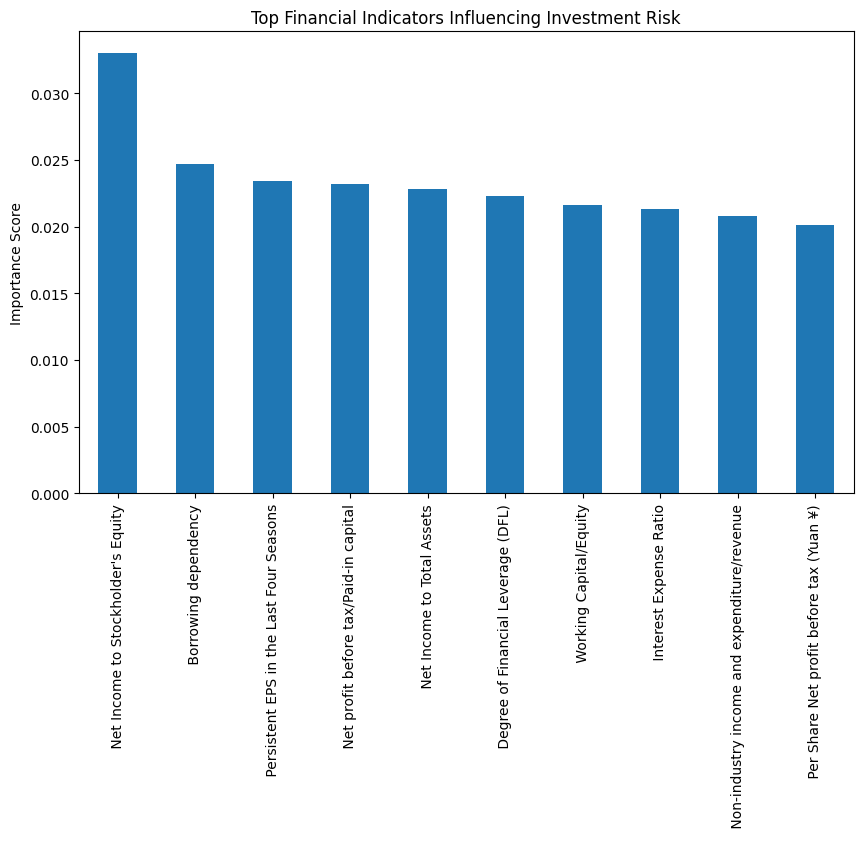

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

importance = pd.Series(
    models["Random Forest"].feature_importances_,
    index=X.columns
)

top_features = importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_features.plot(kind="bar")
plt.title("Top Financial Indicators Influencing Investment Risk")
plt.ylabel("Importance Score")
plt.show()

In [ ]:
y_test_binary = y_test.replace({2:1})

In [ ]:
from sklearn.metrics import roc_curve, auc

rf_model = models["Random Forest"]

probs = rf_model.predict_proba(X_test)[:,1]

y_test_binary = y_test.replace({2:1})

fpr, tpr, threshold = roc_curve(y_test_binary, probs)

roc_auc = auc(fpr, tpr)

In [ ]:
import shap

In [ ]:
explainer = shap.TreeExplainer(models["Random Forest"])
shap_values = explainer.shap_values(X_test)

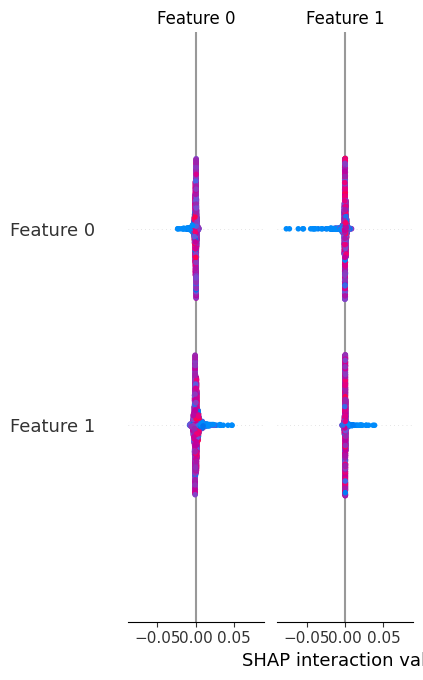

In [ ]:
shap.summary_plot(shap_values, X_test)

In [ ]:
X_test_df = pd.DataFrame(X_test, columns=X.columns)

In [ ]:
explainer = shap.TreeExplainer(models["Random Forest"])
shap_values = explainer.shap_values(X_test_df)

In [ ]:
print(type(shap_values))
print(len(shap_values))
print(shap_values[0].shape)

<class 'numpy.ndarray'>
1364
(95, 2)


In [ ]:
shap.initjs()

shap.force_plot(
    explainer.expected_value[1],
    shap_values[0,:,1],
    X_test_df.iloc[0]
)

In [ ]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)

    results.append({
        "Model": name,
        "Accuracy": acc
    })

performance_df = pd.DataFrame(results)

performance_df

,Model,Accuracy
0,Logistic Regression,0.964076
1,Decision Tree,0.953079
2,Random Forest,0.967009


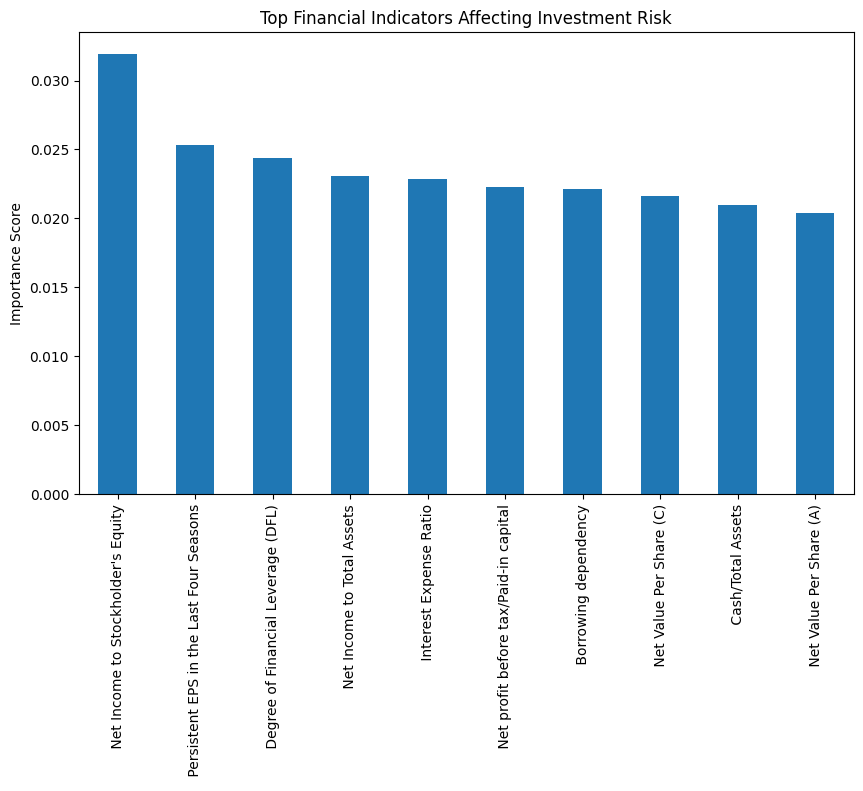

In [ ]:
importance = pd.Series(
    models["Random Forest"].feature_importances_,
    index=X.columns
)

top_features = importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_features.plot(kind="bar")

plt.title("Top Financial Indicators Affecting Investment Risk")
plt.ylabel("Importance Score")

plt.show()

In [ ]:
risk_prob = models["Random Forest"].predict_proba(X_test)

In [ ]:
risk_score = risk_prob[:,1] * 100

In [ ]:
def categorize_risk(score):

    if score < 33:
        return "Low"

    elif score < 66:
        return "Medium"

    else:
        return "High"

risk_category = [categorize_risk(s) for s in risk_score]

In [ ]:
risk_results = pd.DataFrame({

    "Risk Score": risk_score,
    "Risk Category": risk_category
})

risk_results.head()

,Risk Score,Risk Category
0,0.5,Low
1,0.0,Low
2,0.0,Low
3,28.5,Low
4,9.5,Low


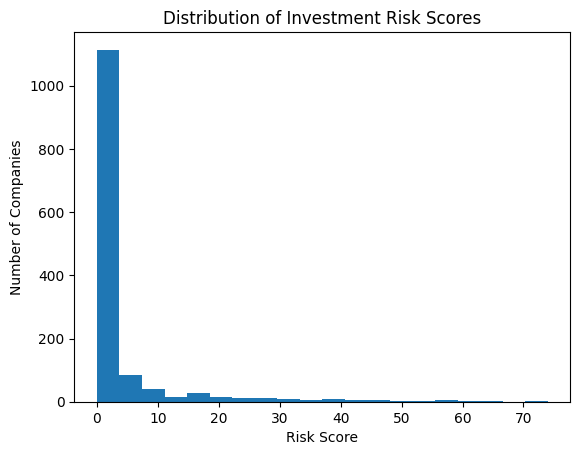

In [ ]:
plt.hist(risk_score, bins=20)

plt.title("Distribution of Investment Risk Scores")
plt.xlabel("Risk Score")
plt.ylabel("Number of Companies")

plt.show()

In [ ]:
!apt-get install graphviz -y
!pip install graphviz


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [ ]:
from graphviz import Digraph

arch = Digraph(format='png')
arch.attr(rankdir='TB', dpi='300')
arch.attr('node', shape='rectangle', style='filled', fillcolor='lightgray')

# Layers
arch.node('A', 'Input Layer\n(Financial Data Input)')
arch.node('B', 'Preprocessing Layer\n- Data Cleaning\n- Missing Value Handling\n- Feature Scaling')
arch.node('C', 'Feature Extraction Layer\n- Financial Indicators\n- Feature Selection')
arch.node('D', 'Model Layer\n(Random Forest Model)\n- Train (offline)\n- Predict (real-time)')
arch.node('E', 'Output Layer\n- Risk Score (0–100)\n- Risk Category\n(Low / Medium / High)')
arch.node('F', 'Explainability Layer\n(SHAP Analysis)')
arch.node('G', 'Deployment Layer\n- Web/App Integration\n- Real-time Prediction')

# Flow
arch.edge('A','B')
arch.edge('B','C')
arch.edge('C','D')
arch.edge('D','E')
arch.edge('E','F')
arch.edge('F','G')

arch.render('ieee_system_architecture', view=True)

'ieee_system_architecture.png'

In [ ]:
from graphviz import Digraph

flow = Digraph(format='png')
flow.attr(rankdir='TB', dpi='300')

flow.attr('node', shape='oval')
flow.node('start', 'Start')

flow.attr('node', shape='box')
flow.node('input', 'Input Financial Data')
flow.node('pre', 'Preprocessing\n- Clean Data\n- Normalize')
flow.node('feat', 'Feature Extraction\n- Financial Indicators')
flow.node('model', 'Model Prediction\n(Random Forest)')
flow.node('prob', 'Generate Risk Probability')
flow.node('score', 'Convert to Risk Score (0–100)')

flow.attr('node', shape='diamond')
flow.node('check', 'Risk Valid?')

flow.attr('node', shape='box')
flow.node('shap', 'SHAP Explanation\nFeature Contribution')
flow.node('output', 'Final Output\nRisk Score + Category')

flow.attr('node', shape='oval')
flow.node('end', 'End')

# Flow connections
flow.edge('start','input')
flow.edge('input','pre')
flow.edge('pre','feat')
flow.edge('feat','model')
flow.edge('model','prob')
flow.edge('prob','score')
flow.edge('score','check')

flow.edge('check','shap', label='Yes')
flow.edge('check','input', label='No')

flow.edge('shap','output')
flow.edge('output','end')

flow.render('ieee_flowchart', view=True)

'ieee_flowchart.png'